In [1]:
import pandas as pd
from statsmodels.tsa.api import VAR
import numpy as np
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

In [31]:
df_combined = pd.read_csv('/home/dhruvkumarjiguda/code/pynb/4thFeb_df_combined.csv')

In [33]:
# df_combined_train = df_combined.iloc[:547] # Train
# df_combined_test = df_combined.iloc[547:699] # Test
# df_combined[df_combined['system__count']==1]
df_combined

,count,shuttle_scan_success_time,shuttle_post_scan_delay,shuttle_carrier_motion_time,shuttle_stopper_lowering_time,shuttle_pallet_release_time,shuttle_stopper_rising_time,shuttle_idle_time,buffer_a__buffer_holding_time,buffer_a__buffer_idle_time,...,total_time,rolling_uph,ng_pallets,yield,total_units,total_pallets,ok_pallets,line,buffer_a__buffer_holding_and_pre_stopper_down_time,buffer_a__buffer_pallet_release_and_pre_stopper_up_time
0,1.0,2.060,0.537,0.003,0.106,2.931,0.084,5.300,0.000,8.474,...,51277.44,208.0,0.0,100.0,2222.0,2222.0,2222.0,l1,-1.000,-1.000
1,3.0,0.000,0.506,3.934,0.084,3.030,0.083,4.951,-1.000,15.844,...,51292.14,208.0,0.0,100.0,2223.0,2223.0,2223.0,l2,0.001,2.824
2,4.0,0.000,0.506,0.000,0.084,2.927,0.084,1.345,3.328,15.683,...,51302.36,208.0,0.0,100.0,2224.0,2224.0,2224.0,l1,-1.000,-1.000
3,5.0,0.000,0.506,4.439,0.084,3.026,0.084,5.450,-1.000,20.114,...,51314.10,208.0,0.0,100.0,2225.0,2225.0,2225.0,l2,0.000,2.826
4,6.0,0.001,0.504,0.000,0.084,2.927,0.084,3.850,1.917,17.123,...,51324.40,208.0,0.0,100.0,2226.0,2226.0,2226.0,l1,-1.000,-1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,96.0,0.000,0.505,0.000,0.104,2.927,0.083,5.420,0.781,8.654,...,64838.27,267.0,0.0,100.0,3389.0,3389.0,3389.0,l1,-1.000,-1.000
1122,97.0,0.000,0.505,4.332,0.106,2.925,0.085,5.149,-1.000,0.001,...,64850.17,267.0,0.0,100.0,3390.0,3390.0,3390.0,l2,19.915,2.927
1123,98.0,0.000,0.504,0.202,0.104,2.927,0.083,11.651,11.365,19.428,...,64860.48,267.0,0.0,100.0,3391.0,3391.0,3391.0,l1,-1.000,-1.000
1124,99.0,0.000,0.506,4.140,0.105,2.924,0.084,4.949,1.636,19.421,...,64876.93,267.0,0.0,100.0,3392.0,3392.0,3392.0,l1,-1.000,-1.000


In [4]:
df_combined_train = df_combined_train.drop(columns=['system__count'])
df_combined_test = df_combined_test.drop(columns=['system__count'])

# df_combined.columns

In [5]:
# station_df = df_combined.groupby(
#     lambda c: c.split('__')[0], axis=1).sum()

# station_df

station_df_train = (
    df_combined_train
    .T
    .groupby(lambda c: c.split('__')[0])
    .sum()
    .T
)

station_df_test = (
    df_combined_test
    .T
    .groupby(lambda c: c.split('__')[0])
    .sum()
    .T
)

# station_df_train

In [21]:
test_df = station_df_test.copy()
train_df = station_df_train.copy()

In [22]:
train_df = train_df[3:].reset_index(drop=True)
test_df = test_df[3:].reset_index(drop=True)

In [14]:
# test_df
# train_df
train_df.dtypes

l1_buffer_a        object
l1_buffer_b        object
l1_dispenser       object
l1_inspection      object
l2_buffer_a        object
l2_buffer_b        object
l2_dispenser       object
l2_inspection      object
line               object
shuttle_station    object
system             object
timestamp          object
dtype: object

In [9]:
LAG_STEPS = 3
FORECAST_STEPS = 20

In [23]:
train_df = train_df.apply(pd.to_numeric, errors='coerce')

In [24]:
model = VAR(train_df.drop(columns=['timestamp']))
results = model.fit(maxlags=LAG_STEPS)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 11, Mar, 2026
Time:                     12:11:44
--------------------------------------------------------------------
No. of Equations:         11.0000    BIC:                   -17.0944
Nobs:                     541.000    HQIC:                  -18.9018
Log likelihood:          -2643.19    FPE:                1.93976e-09
AIC:                     -20.0625    Det(Omega_mle):     9.92135e-10
--------------------------------------------------------------------
Results for equation l1_buffer_a
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                     17.246786        74.370036            0.232           0.817
L1.l1_buffer_a            -0.019372         0.104404           -0.186           0.853
L1.l1_buffer_b             0.88518

In [25]:
lag_order = results.k_ar

data = train_df.drop(columns=['timestamp']).values

predictions = []

for i in range(lag_order, len(data)):
    
    # last lag_order observations
    input_window = data[i-lag_order:i]
    
    # predict next step
    pred = results.forecast(input_window, steps=FORECAST_STEPS)
    
    predictions.append(pred[0])

# convert to dataframe
pred_df = pd.DataFrame(predictions, columns=train_df.drop(columns=['timestamp']).columns)

# align timestamps
pred_df["timestamp"] = train_df["timestamp"].iloc[lag_order:].values
pred_df = pred_df.reset_index(drop=True)

# temp = train_df.drop(columns=['timestamp']).iloc[lag_order:].reset_index(drop=True)
temp = train_df.drop(columns=['timestamp']).reset_index(drop=True)

l1_buffer_a RMSE : 2.2661570912782816


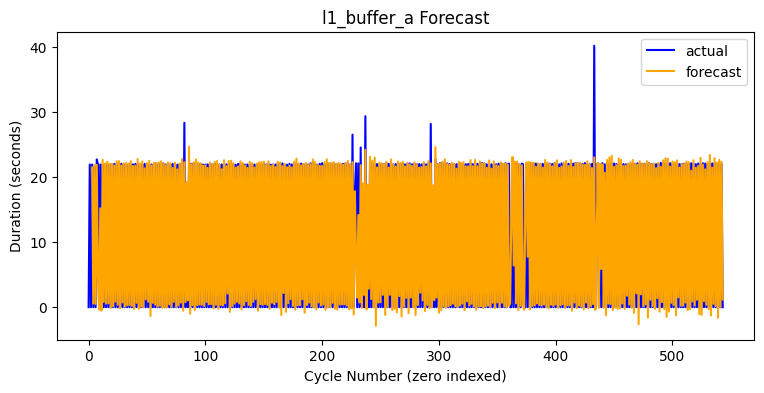

l1_buffer_b RMSE : 2.157078479055896


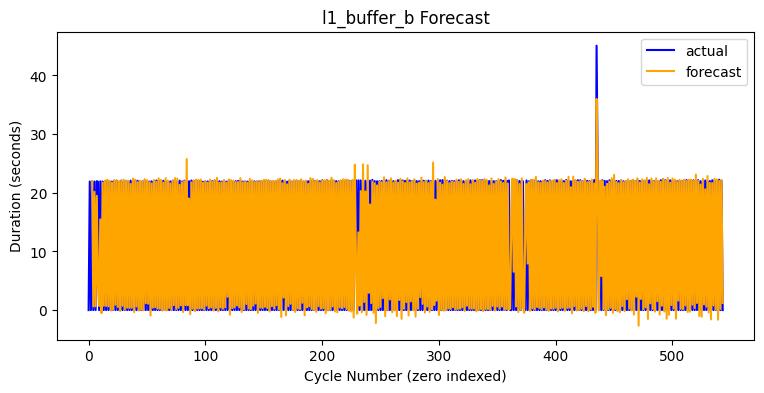

l1_dispenser RMSE : 2.053438363688196


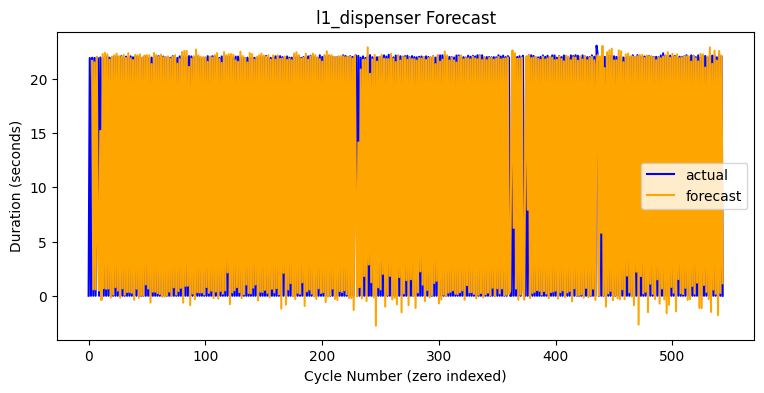

l1_inspection RMSE : 2.0502203768934457


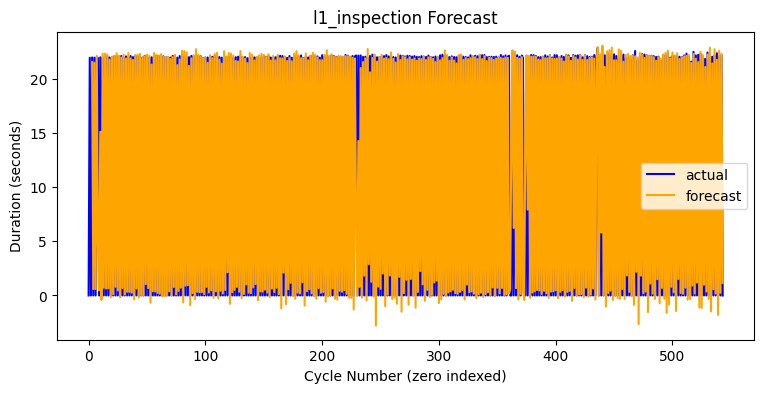

l2_buffer_a RMSE : 3.618604151244907


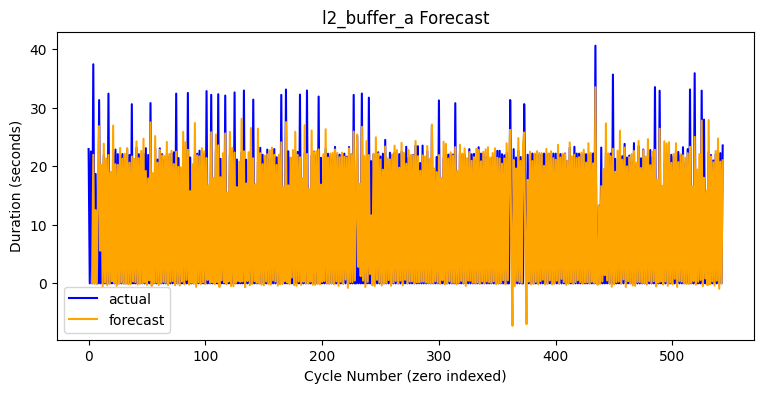

l2_buffer_b RMSE : 2.4667270674693316


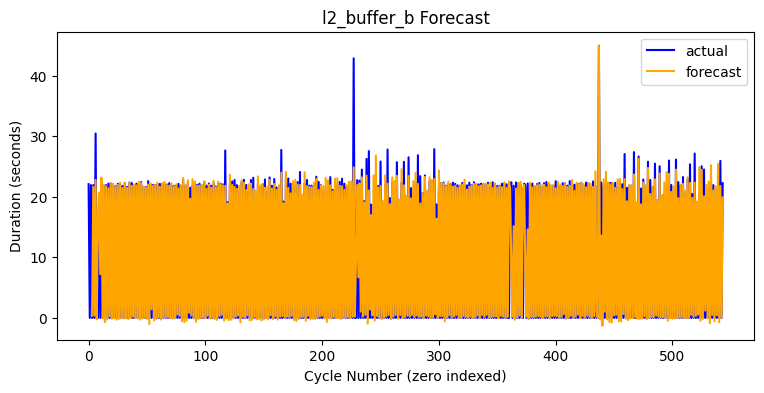

l2_dispenser RMSE : 2.2078475204292474


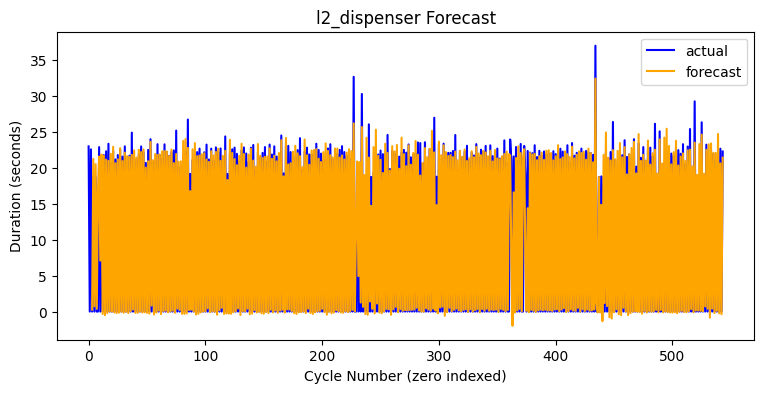

l2_inspection RMSE : 2.057514626772436


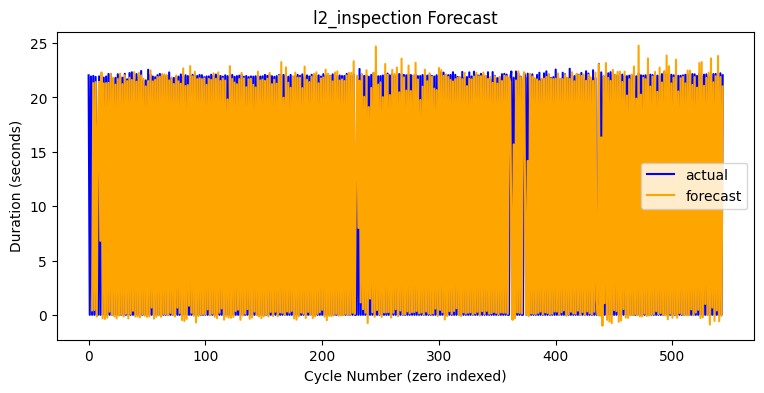

line RMSE : 0.09311118583665015


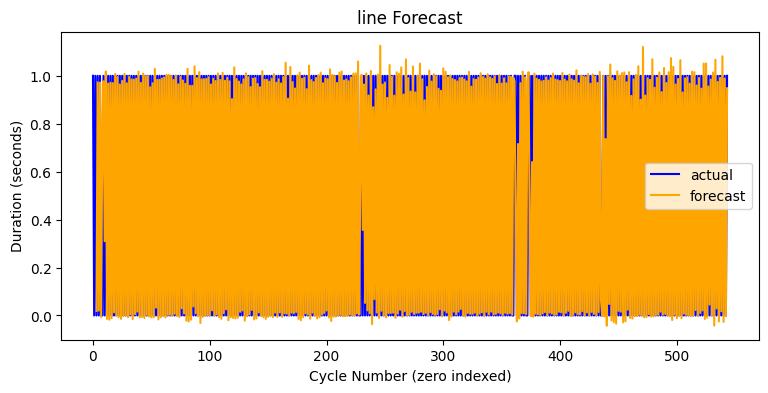

shuttle_station RMSE : 1.4196938346024386


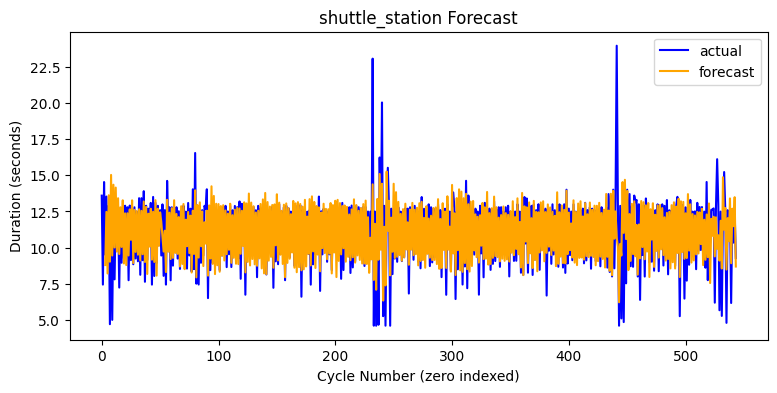

system RMSE : 0.25344656294731605


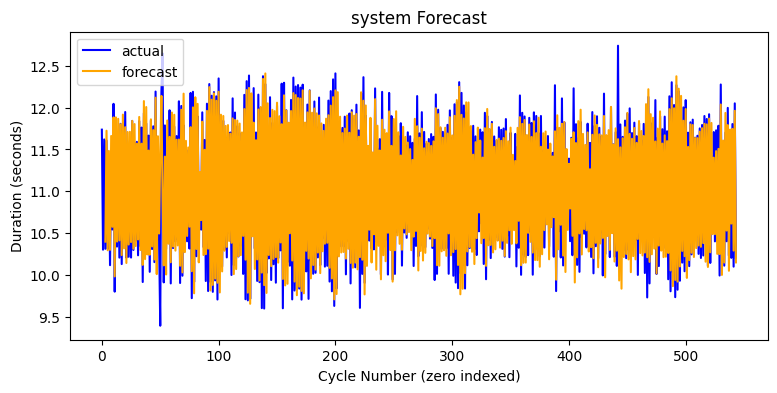

In [26]:
for column in temp.columns:
    rmse = root_mean_squared_error(temp[column].iloc[lag_order:],pred_df[column])
    print(f"{column} RMSE : {rmse}")
    plt.figure(figsize=(9,4))
    plt.plot(temp[column],color='blue',label='actual')
    # plt.plot(pred_df[column],color='orange',label='forecast')
    plt.plot(
        range(lag_order, lag_order + len(pred_df[column])),
        pred_df[column],
        color='orange',
        label='forecast'
    )
    plt.title(f"{column} Forecast")
    plt.xlabel("Cycle Number (zero indexed)")
    plt.ylabel("Duration (seconds)")
    plt.legend()
    plt.show()